# Angular-spectrum tractability benchmark

This notebook tests computational reductions for the maintained 30 keV, 2 degree glancing-incidence silicon problem without replacing the angular-spectrum propagator. The complex128, 0.2 Angstrom multislice calculation is the reference.

The tested changes are: adaptive low-rank compression of arbitrary input probes; complex64 propagation; integrated phase screens at 2, 3, and 4 screens per unit cell; screens aligned to the actual projected atomic planes; combined low-rank/coarse/complex64 calculations; and rematerialized differentiation. No potential is decimated: every coarse transmission contains the integral of the fine potential assigned to that screen.

The implementation is one-transverse-dimensional because that is the current side-view model. The methods themselves generalize directly to two transverse dimensions: flatten `(ny, nx)` only for the probe SVD, replace `fft` by `fft2`, and retain the same axial partitions and projected transmissions.

In [1]:
from __future__ import annotations

from dataclasses import dataclass
import gc
from pathlib import Path
from time import perf_counter

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from ase import Atoms
from ase.build import bulk
import abtem

repo_root = Path.cwd()
if not (repo_root / "wide_angle_propagation").is_dir():
    repo_root = repo_root.parent.parent
if not (repo_root / "wide_angle_propagation").is_dir():
    raise RuntimeError("Run this notebook from the repository or notebooks/verification")

from wide_angle_propagation.propagation_methods import (
    energy2wavelength,
    interaction_constant,
)

print({"devices": jax.devices(), "x64 enabled": jax.config.x64_enabled})

{'devices': [CudaDevice(id=0)], 'x64 enabled': True}


## Configuration

`FULL_LENGTH=True` reproduces the complete 1000 Angstrom calculation. Set it to `False` for a compilation and API smoke test. Compilation is excluded from reported runtimes. Gradient benchmarks are separate because reverse-mode memory can be large. The full variant-gradient sweep is opt-in and is best run one variant per fresh process on a shared GPU; the checkpoint comparison remains enabled independently.

In [2]:
FULL_LENGTH = True
RUN_COMBINED_VARIANTS = True
RUN_GRADIENT_BENCHMARKS = True
RUN_VARIANT_GRADIENT_ACCURACY = True
TIMING_REPEATS = 3
PROBE_RESIDUAL_TOL = 1e-5
ACCEPTED_AMPLITUDE_NRMSE = 1e-3

energy_eV = 30_000.0
glancing_angle_deg = 2.0
beam_tilt_rad = -np.deg2rad(glancing_angle_deg)
convergence_mrad = 15.0
propagation_length_A = 1000.0 if FULL_LENGTH else 120.0
slab_depth_A = 50.0
vacuum_above_A, vacuum_below_A = 40.0, 20.0
si_lattice_A = 5.431
requested_du_A, requested_ds_A = 0.115, 0.20
scan_coordinates_A = (
    np.linspace(400.0, 600.0, 21)
    if FULL_LENGTH
    else np.linspace(45.0, 75.0, 7)
)
wavelength_A = float(energy2wavelength(energy_eV))
sigma = float(interaction_constant(energy_eV))
print({"wavelength A": wavelength_A, "interaction constant": sigma})

{'wavelength A': 0.06979081544914424, 'interaction constant': 0.0015432699161451685}


## Fine-grid atomic reference

The finite-projection Lobato potential is generated once on the present fine grid. Coarse variants integrate this reference along the propagation axis. This isolates axial multislice error from changes in the atomic parametrization. In a production 3D implementation, the same projected screens should be accumulated directly from atom-local templates or analytic atom integrals rather than first rendering the full fine volume.

In [3]:
surface_global_A = vacuum_below_A + slab_depth_A
transverse_extent_A = vacuum_below_A + slab_depth_A + vacuum_above_A
si_unit = bulk("Si", "diamond", a=si_lattice_A, cubic=True)
surface_clearance_A = si_lattice_A / 8.0
n_depth_cells = int(np.ceil(slab_depth_A / si_lattice_A)) + 1
n_length_cells = int(np.ceil(propagation_length_A / si_lattice_A)) + 1
repeated = si_unit.repeat((n_depth_cells, 1, n_length_cells))
positions_A = repeated.positions
inside = (
    (positions_A[:, 0] <= slab_depth_A - surface_clearance_A + 1e-9)
    & (positions_A[:, 2] < propagation_length_A - 1e-9)
)
positions_A = positions_A[inside].copy()
positions_A[:, 0] = surface_global_A - surface_clearance_A - positions_A[:, 0]
si_slab = Atoms(
    ["Si"] * len(positions_A),
    positions=positions_A,
    cell=(transverse_extent_A, si_lattice_A, propagation_length_A),
    pbc=(False, True, False),
)
builder = abtem.Potential(
    si_slab, sampling=(requested_du_A, requested_ds_A),
    slice_thickness=si_lattice_A, projection="finite",
    parametrization="lobato", plane="xz", periodic=False, device="cpu",
)
finite_projected = np.asarray(builder.build(lazy=False).array)[0]
du_A, ds_A = map(float, builder.sampling)
n_u, n_s = finite_projected.shape
s_A = np.arange(n_s) * ds_A
u_A = np.arange(n_u) * du_A - surface_global_A
potential_fine = np.ascontiguousarray(finite_projected.T / si_lattice_A)
axial_atom_planes_A = np.unique(np.round(positions_A[:, 2], decimals=8))
print({
    "potential shape": potential_fine.shape,
    "sampling (ds, du) A": (ds_A, du_A),
    "atoms": len(positions_A),
    "projected atom planes": len(axial_atom_planes_A),
})

{'potential shape': (5000, 957), 'sampling (ds, du) A': (0.2, 0.11494252873563218), 'atoms': 13635, 'projected atom planes': 737}


In [4]:
frequencies_inv_A = np.fft.fftfreq(n_u, d=du_A)
qx, qy = np.meshgrid(frequencies_inv_A, frequencies_inv_A, indexing="xy")
aperture_radius_inv_A = np.sin(convergence_mrad * 1e-3) / wavelength_A
pupil = qx**2 + qy**2 <= aperture_radius_inv_A**2
probe_2d = np.fft.fftshift(np.fft.ifft2(pupil))
probe_line = probe_2d[n_u // 2]
probe_line /= np.max(np.abs(probe_line)) + 1e-30
probe_spectrum = np.fft.fft(probe_line)
beam_centres_A = -scan_coordinates_A * np.tan(beam_tilt_rad)
carrier = np.exp(2j * np.pi * np.sin(beam_tilt_rad) * u_A / wavelength_A)
array_centre_A = float(u_A[n_u // 2])
input_probes = np.stack([
    np.fft.ifft(
        probe_spectrum
        * np.exp(-2j * np.pi * frequencies_inv_A * (centre - array_centre_A))
    ) * carrier
    for centre in beam_centres_A
])
input_probes = np.asarray(input_probes, dtype=np.complex128)
print({"probe matrix": input_probes.shape, "entrance span A": np.ptp(beam_centres_A)})

{'probe matrix': (21, 957), 'entrance span A': 6.984153898349545}


## Adaptive probe compression

The SVD is object-independent. It accepts any probe matrix and chooses the smallest rank meeting the requested Frobenius residual. If unrelated probes are not compressible, the selected rank approaches the number of probes and the method becomes the original calculation. In 3D, each probe is flattened only for this factorization; propagated modes retain their 2D shape.

{'probes': 21, 'selected modes': 10, 'input residual': 1.4449132838366485e-06, 'ideal mode speedup': 2.1}


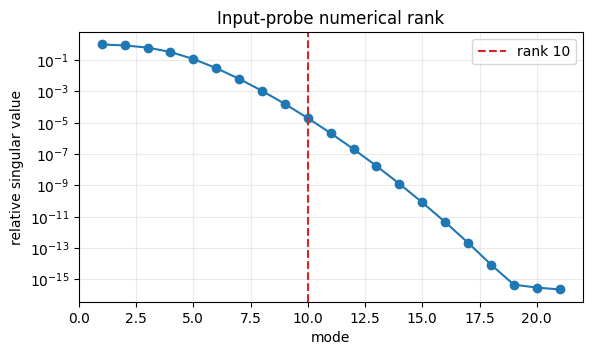

In [5]:
def compress_probes(probes, residual_tolerance):
    left, singular, right_h = np.linalg.svd(probes, full_matrices=False)
    tail_energy = np.maximum(0.0, 1.0 - np.cumsum(singular**2) / np.sum(singular**2))
    residuals = np.sqrt(tail_energy)
    accepted = np.flatnonzero(residuals <= residual_tolerance)
    rank = int(accepted[0] + 1) if len(accepted) else len(singular)
    modes = right_h[:rank]
    coefficients = left[:, :rank] * singular[:rank]
    return modes, coefficients, singular, residuals

compressed_modes, compressed_coefficients, probe_singular, probe_residuals = compress_probes(
    input_probes, PROBE_RESIDUAL_TOL
)
compressed_rank = compressed_modes.shape[0]
print({
    "probes": len(input_probes),
    "selected modes": compressed_rank,
    "input residual": float(probe_residuals[compressed_rank - 1]),
    "ideal mode speedup": len(input_probes) / compressed_rank,
})
fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.semilogy(np.arange(1, len(probe_singular) + 1), probe_singular / probe_singular[0], "o-")
ax.axvline(compressed_rank, color="tab:red", linestyle="--", label=f"rank {compressed_rank}")
ax.set(xlabel="mode", ylabel="relative singular value", title="Input-probe numerical rank")
ax.grid(True, which="both", alpha=0.25)
ax.legend();

## Axial partitions

Uniform partitions use 2, 3, or 4 transmission screens per unit cell. Atom-aligned partitions assign each fine axial cell to its nearest actual projected atomic plane and place the integrated transmission on that plane. The latter is object-general but only advantageous when atom coordinates form shared planes; a disordered object can produce nearly one screen per distinct atom coordinate. A practical 3D implementation should cluster nearby axial atom coordinates with a physical tolerance.

In [6]:
@dataclass(frozen=True)
class SlicePartition:
    name: str
    segment_ids: np.ndarray
    screen_positions_A: np.ndarray

    @property
    def n_screens(self):
        return len(self.screen_positions_A)

def partition_from_starts(name, starts):
    starts = np.unique(np.r_[0, np.asarray(starts, dtype=int)])
    starts = starts[(starts >= 0) & (starts < n_s)]
    ends = np.r_[starts[1:], n_s]
    ids = np.empty(n_s, dtype=np.int32)
    positions = []
    for index, (start, end) in enumerate(zip(starts, ends)):
        ids[start:end] = index
        positions.append(float(np.mean(s_A[start:end])))
    return SlicePartition(name, ids, np.asarray(positions))

def uniform_partition(screens_per_cell):
    target_A = si_lattice_A / screens_per_cell
    starts = np.rint(np.arange(0.0, n_s * ds_A, target_A) / ds_A).astype(int)
    return partition_from_starts(f"uniform {screens_per_cell}/cell", starts)

def atom_aligned_partition(atom_planes_A):
    planes = np.asarray(atom_planes_A)
    planes = planes[(planes >= s_A[0]) & (planes <= s_A[-1] + ds_A)]
    boundaries = 0.5 * (planes[:-1] + planes[1:])
    ids = np.searchsorted(boundaries, s_A, side="right").astype(np.int32)
    occupied = np.unique(ids)
    remap = np.full(ids.max() + 1, -1, dtype=np.int32)
    remap[occupied] = np.arange(len(occupied), dtype=np.int32)
    return SlicePartition("atom aligned", remap[ids], planes[occupied])

fine_partition = SlicePartition("fine 0.2 A", np.arange(n_s, dtype=np.int32), s_A.copy())
partitions = [fine_partition, uniform_partition(2), uniform_partition(3), uniform_partition(4)]
partitions.append(atom_aligned_partition(axial_atom_planes_A))
for partition in partitions:
    print(f"{partition.name:16s}: {partition.n_screens:5d} screens, {n_s / partition.n_screens:6.2f}x fewer")

fine 0.2 A      :  5000 screens,   1.00x fewer
uniform 2/cell  :   369 screens,  13.55x fewer
uniform 3/cell  :   553 screens,   9.04x fewer
uniform 4/cell  :   737 screens,   6.78x fewer
atom aligned    :   737 screens,   6.78x fewer


## Exact angular-spectrum screen propagator

Each screen applies `exp(i sigma V_projected)`. Exact angular-spectrum propagation is used between screen positions, including the initial and final fractional distances. A small bank stores kernels only for unique propagation distances, so an atom-aligned grid does not allocate one full kernel per screen.

In [7]:
def kernel_bank_for_partition(partition, complex_dtype):
    positions = partition.screen_positions_A
    total_length_A = n_s * ds_A
    distances = np.r_[positions[0], np.diff(positions), total_length_A - positions[-1]]
    rounded = np.round(distances, decimals=10)
    unique_distances, kernel_ids = np.unique(rounded, return_inverse=True)
    real_dtype = np.float32 if complex_dtype == np.complex64 else np.float64
    frequencies = np.fft.fftfreq(n_u, d=du_A).astype(real_dtype)
    inverse_lambda = real_dtype(1.0 / wavelength_A)
    kz = np.sqrt(np.maximum(real_dtype(0.0), inverse_lambda**2 - frequencies**2))
    bank = np.exp(2j * np.pi * unique_distances[:, None] * kz[None, :]).astype(complex_dtype)
    return bank, kernel_ids.astype(np.int32)

def make_forward_core(partition, modes, coefficients, complex_dtype, rematerialize=False):
    bank_np, kernel_ids_np = kernel_bank_for_partition(partition, complex_dtype)
    bank = jnp.asarray(bank_np)
    kernel_ids = jnp.asarray(kernel_ids_np)
    segment_ids = jnp.asarray(partition.segment_ids)
    modes_jax = jnp.asarray(modes, dtype=complex_dtype)
    coefficients_jax = None if coefficients is None else jnp.asarray(coefficients, dtype=complex_dtype)
    real_dtype = jnp.float32 if complex_dtype == np.complex64 else jnp.float64
    sigma_typed = jnp.asarray(sigma, dtype=real_dtype)
    ds_typed = jnp.asarray(ds_A, dtype=real_dtype)

    def core(potential):
        potential = jnp.asarray(potential, dtype=real_dtype)
        if partition.n_screens == n_s:
            projected = potential * ds_typed
        else:
            projected = jnp.zeros((partition.n_screens, n_u), dtype=real_dtype)
            projected = projected.at[segment_ids].add(potential * ds_typed)
        wave = modes_jax
        wave = jnp.fft.ifft(jnp.fft.fft(wave, axis=-1) * bank[kernel_ids[0]], axis=-1)

        def step(current, payload):
            projected_slice, kernel_id = payload
            current = current * jnp.exp(1j * sigma_typed * projected_slice)
            current = jnp.fft.ifft(
                jnp.fft.fft(current, axis=-1) * bank[kernel_id], axis=-1
            )
            return current, None

        scan_step = jax.checkpoint(step) if rematerialize else step
        wave, _ = jax.lax.scan(scan_step, wave, (projected, kernel_ids[1:]))
        exit_waves = wave if coefficients_jax is None else coefficients_jax @ wave
        return jnp.fft.fftshift(jnp.fft.fft(exit_waves, axis=-1), axes=-1)

    return core

def full_probe_representation():
    return input_probes, None

def compressed_probe_representation():
    return compressed_modes, compressed_coefficients

## Forward benchmarks

Reported time includes fine-to-coarse potential integration and propagation, but excludes JIT compilation. The ideal work speedup counts propagated mode-screen pairs and does not include potential integration, detector reconstruction, or precision-dependent hardware throughput. The detector-amplitude NRMSE is the reconstruction-relevant metric.

In [8]:
detector_frequencies = np.fft.fftshift(np.fft.fftfreq(n_u, d=du_A))
detector_angles_mrad = 1e3 * np.arcsin(
    np.clip(wavelength_A * detector_frequencies, -1.0, 1.0)
)
reflected_mask = (detector_angles_mrad >= 0.0) & (detector_angles_mrad <= 80.0)

def amplitude_nrmse(candidate, reference, mask=None):
    candidate_amplitude = np.asarray(np.abs(candidate), dtype=np.float64)
    reference_amplitude = np.asarray(np.abs(reference), dtype=np.float64)
    if mask is not None:
        candidate_amplitude = candidate_amplitude[:, mask]
        reference_amplitude = reference_amplitude[:, mask]
    return float(np.linalg.norm(candidate_amplitude - reference_amplitude) / np.linalg.norm(reference_amplitude))

def complex_l2(candidate, reference):
    phase = np.vdot(candidate, reference)
    phase = phase / (abs(phase) + 1e-30)
    return float(np.linalg.norm(candidate * phase - reference) / np.linalg.norm(reference))

def compile_and_time(core, potential, repeats=TIMING_REPEATS):
    device_potential = jax.device_put(np.asarray(potential))
    started = perf_counter()
    executable = jax.jit(core).lower(device_potential).compile()
    compile_seconds = perf_counter() - started
    output = executable(device_potential)
    output.block_until_ready()
    timings = []
    for _ in range(repeats):
        started = perf_counter()
        output = executable(device_potential)
        output.block_until_ready()
        timings.append(perf_counter() - started)
    return np.asarray(output), float(np.median(timings)), compile_seconds

@dataclass(frozen=True)
class Variant:
    name: str
    partition: SlicePartition
    dtype: type
    compressed: bool

partition_by_name = {partition.name: partition for partition in partitions}
variants = [
    Variant("reference fine c128", fine_partition, np.complex128, False),
    Variant("fine c64", fine_partition, np.complex64, False),
    Variant("fine c128 compressed", fine_partition, np.complex128, True),
]
for name in ("uniform 2/cell", "uniform 3/cell", "uniform 4/cell", "atom aligned"):
    variants.append(Variant(f"{name} c128", partition_by_name[name], np.complex128, False))
if RUN_COMBINED_VARIANTS:
    for name in ("uniform 2/cell", "uniform 3/cell", "uniform 4/cell", "atom aligned"):
        variants.append(Variant(f"{name} c64 compressed", partition_by_name[name], np.complex64, True))

In [9]:
results = []
reference_detector = None
reference_time = None
for variant in variants:
    modes, coefficients = (
        compressed_probe_representation() if variant.compressed else full_probe_representation()
    )
    core = make_forward_core(
        variant.partition, modes, coefficients, variant.dtype, rematerialize=False
    )
    potential_dtype = np.float32 if variant.dtype == np.complex64 else np.float64
    potential_for_variant = np.asarray(potential_fine, dtype=potential_dtype)
    detector, runtime, compile_time = compile_and_time(core, potential_for_variant)
    if reference_detector is None:
        reference_detector = detector
        reference_time = runtime
    n_modes = len(modes)
    row = {
        "name": variant.name,
        "screens": variant.partition.n_screens,
        "modes": n_modes,
        "dtype": np.dtype(variant.dtype).name,
        "runtime_s": runtime,
        "compile_s": compile_time,
        "measured_speedup": reference_time / runtime,
        "ideal_work_speedup": (n_s * len(input_probes)) / (variant.partition.n_screens * n_modes),
        "complex_l2": complex_l2(detector, reference_detector),
        "amplitude_nrmse": amplitude_nrmse(detector, reference_detector),
        "reflected_nrmse": amplitude_nrmse(detector, reference_detector, reflected_mask),
    }
    results.append(row)
    print(row)

{'name': 'reference fine c128', 'screens': 5000, 'modes': 21, 'dtype': 'complex128', 'runtime_s': 0.4270179039449431, 'compile_s': 0.18498998996801674, 'measured_speedup': 1.0, 'ideal_work_speedup': 1.0, 'complex_l2': 0.0, 'amplitude_nrmse': 0.0, 'reflected_nrmse': 0.0}
{'name': 'fine c64', 'screens': 5000, 'modes': 21, 'dtype': 'complex64', 'runtime_s': 0.3792737580370158, 'compile_s': 0.16349786904174834, 'measured_speedup': 1.125883072309125, 'ideal_work_speedup': 1.0, 'complex_l2': 0.0012973458282182714, 'amplitude_nrmse': 0.0008935819459902261, 'reflected_nrmse': 0.0007760861288687379}
{'name': 'fine c128 compressed', 'screens': 5000, 'modes': 10, 'dtype': 'complex128', 'runtime_s': 0.4210275199729949, 'compile_s': 0.18229911604430526, 'measured_speedup': 1.0142280104928352, 'ideal_work_speedup': 2.1, 'complex_l2': 1.444970740009027e-06, 'amplitude_nrmse': 1.0573445712354091e-06, 'reflected_nrmse': 1.3657196476724454e-06}
{'name': 'uniform 2/cell c128', 'screens': 369, 'modes': 21

Accepted variants, fastest first:
fine c64 {'measured_speedup': 1.125883072309125, 'amplitude_nrmse': 0.0008935819459902261, 'reflected_nrmse': 0.0007760861288687379}
fine c128 compressed {'measured_speedup': 1.0142280104928352, 'amplitude_nrmse': 1.0573445712354091e-06, 'reflected_nrmse': 1.3657196476724454e-06}
reference fine c128 {'measured_speedup': 1.0, 'amplitude_nrmse': 0.0, 'reflected_nrmse': 0.0}


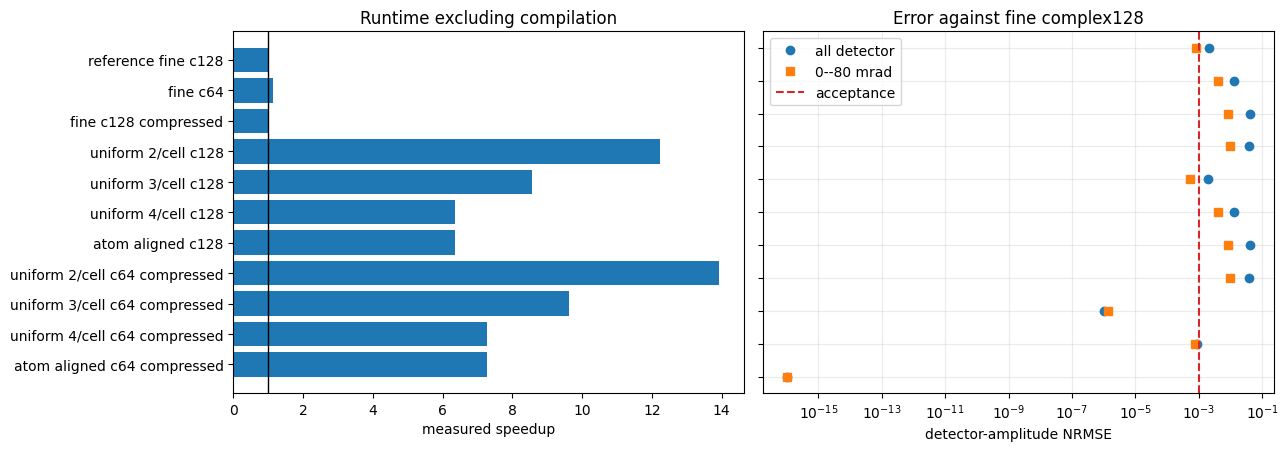

In [10]:
names = [row["name"] for row in results]
speedups = np.asarray([row["measured_speedup"] for row in results])
errors = np.asarray([row["amplitude_nrmse"] for row in results])
band_errors = np.asarray([row["reflected_nrmse"] for row in results])
fig, axes = plt.subplots(1, 2, figsize=(13, max(4.5, 0.42 * len(names))))
y = np.arange(len(names))
axes[0].barh(y, speedups, color="tab:blue")
axes[0].axvline(1.0, color="black", linewidth=1)
axes[0].set(xlabel="measured speedup", yticks=y, yticklabels=names, title="Runtime excluding compilation")
axes[0].invert_yaxis()
axes[1].semilogx(np.maximum(errors, 1e-16), y, "o", label="all detector")
axes[1].semilogx(np.maximum(band_errors, 1e-16), y, "s", label="0--80 mrad")
axes[1].axvline(ACCEPTED_AMPLITUDE_NRMSE, color="tab:red", linestyle="--", label="acceptance")
axes[1].set(xlabel="detector-amplitude NRMSE", yticks=y, yticklabels=[], title="Error against fine complex128")
axes[1].grid(True, which="both", alpha=0.25)
axes[1].legend()
fig.tight_layout();

accepted = [
    row for row in results
    if row["amplitude_nrmse"] <= ACCEPTED_AMPLITUDE_NRMSE
    and row["reflected_nrmse"] <= ACCEPTED_AMPLITUDE_NRMSE
]
accepted = sorted(accepted, key=lambda row: row["measured_speedup"], reverse=True)
print("Accepted variants, fastest first:")
for row in accepted:
    print(row["name"], {key: row[key] for key in ("measured_speedup", "amplitude_nrmse", "reflected_nrmse")})

## Isolating precision and axial errors

The next summaries separate complex64 error from coarse-screen error. A coarse result can fail because of noncommuting diffraction and transmission even though its integrated potential is exact. Alignment with atomic planes is therefore a hypothesis to test, not an assumed improvement.

In [11]:
print("Independent changes:")
for row in results[:7]:
    print(
        f"{row['name']:28s} screens={row['screens']:5d} modes={row['modes']:2d} "
        f"speedup={row['measured_speedup']:6.2f} "
        f"all={row['amplitude_nrmse']:.3e} reflected={row['reflected_nrmse']:.3e}"
    )

Independent changes:
reference fine c128          screens= 5000 modes=21 speedup=  1.00 all=0.000e+00 reflected=0.000e+00
fine c64                     screens= 5000 modes=21 speedup=  1.13 all=8.936e-04 reflected=7.761e-04
fine c128 compressed         screens= 5000 modes=10 speedup=  1.01 all=1.057e-06 reflected=1.366e-06
uniform 2/cell c128          screens=  369 modes=21 speedup= 12.25 all=3.724e-02 reflected=9.692e-03
uniform 3/cell c128          screens=  553 modes=21 speedup=  8.55 all=4.254e-02 reflected=8.487e-03
uniform 4/cell c128          screens=  737 modes=21 speedup=  6.35 all=1.262e-02 reflected=3.947e-03
atom aligned c128            screens=  737 modes=21 speedup=  6.36 all=1.971e-03 reflected=5.455e-04


## Gradient and rematerialization benchmark

A localized atom-like perturbation amplitude is differentiated through the complete propagation. The test compares ordinary reverse mode with `jax.checkpoint` applied to the scan step. Both must return the same objective and derivative. The stored-wave lower bound is reported analytically because portable peak-device-memory reset/readback is not available on every JAX backend.

Rematerialization reduces saved intermediates but recomputes forward operations during the backward pass; it is a memory optimization, not a forward speed optimization.

In [12]:
def compile_and_time_value_grad(function, repeats=max(1, TIMING_REPEATS - 1)):
    gc.collect()
    jax.clear_caches()
    transformed = jax.jit(jax.value_and_grad(function))
    started = perf_counter()
    executable = transformed.lower(jnp.asarray(0.0, dtype=jnp.float64)).compile()
    compile_seconds = perf_counter() - started
    value, gradient = executable(jnp.asarray(0.0, dtype=jnp.float64))
    value.block_until_ready()
    timings = []
    for _ in range(repeats):
        started = perf_counter()
        value, gradient = executable(jnp.asarray(0.0, dtype=jnp.float64))
        value.block_until_ready()
        timings.append(perf_counter() - started)
    return float(value), float(gradient), float(np.median(timings)), compile_seconds

if RUN_GRADIENT_BENCHMARKS:
    s0 = 0.5 * propagation_length_A
    perturbation = (
        np.exp(-0.5 * ((s_A[:, None] - s0) / 0.45) ** 2)
        * np.exp(-0.5 * ((u_A[None, :] + 1.0) / 0.35) ** 2)
    )
    perturbation /= np.max(perturbation) + 1e-30
    modes, coefficients = compressed_probe_representation()
    objective_rows = []
    for rematerialize in (False, True):
        forward = make_forward_core(
            fine_partition, modes, coefficients, np.complex128, rematerialize=rematerialize
        )
        potential_jax = jnp.asarray(potential_fine)
        perturbation_jax = jnp.asarray(perturbation)
        detector_weight = jnp.asarray(reflected_mask, dtype=jnp.float64)

        def objective(amplitude):
            detector = forward(potential_jax + amplitude * perturbation_jax)
            intensity = jnp.abs(detector) ** 2
            return jnp.sum(jnp.log1p(intensity) * detector_weight) / jnp.sum(detector_weight)

        value, gradient, runtime, compile_time = compile_and_time_value_grad(objective)
        objective_rows.append({
            "rematerialize": rematerialize, "value": value, "gradient": gradient,
            "runtime_s": runtime, "compile_s": compile_time,
        })
        print(objective_rows[-1])
    reference_gradient = objective_rows[0]["gradient"]
    print({
        "checkpoint relative gradient difference": abs(objective_rows[1]["gradient"] - reference_gradient) / (abs(reference_gradient) + 1e-30),
        "wave-stack lower bound GiB": n_s * compressed_rank * n_u * np.dtype(np.complex128).itemsize / 2**30,
    })
else:
    print("Gradient benchmarks disabled")

{'rematerialize': False, 'value': 19.047288068599723, 'gradient': -0.0010320063806312871, 'runtime_s': 0.9953604370239191, 'compile_s': 1.849724963947665}
{'rematerialize': True, 'value': 19.047288068599723, 'gradient': -0.0010320063806312871, 'runtime_s': 0.9764750849863049, 'compile_s': 1.8148064599954523}
{'checkpoint relative gradient difference': 0.0, 'wave-stack lower bound GiB': 0.7130205631256104}


### Gradient accuracy of the approximations

The independent float32, compression, uniform-screen, and atom-aligned variants are differentiated with rematerialization enabled and compared with a full-probe, fine complex128 derivative. This is a scalar directional test, not a proof that every atomic coordinate gradient is converged; any candidate retained for reconstruction should subsequently be checked with several atom-position directions and displaced atoms near screen boundaries.

In [13]:
variant_gradient_rows = []
if RUN_GRADIENT_BENCHMARKS and RUN_VARIANT_GRADIENT_ACCURACY:
    potential_jax = jnp.asarray(potential_fine)
    perturbation_jax = jnp.asarray(perturbation)
    detector_weight = jnp.asarray(reflected_mask, dtype=jnp.float64)
    reference_forward = make_forward_core(
        fine_partition, input_probes, None, np.complex128, rematerialize=True
    )

    def reference_objective(amplitude):
        detector = reference_forward(potential_jax + amplitude * perturbation_jax)
        intensity = jnp.abs(detector) ** 2
        return jnp.sum(jnp.log1p(intensity) * detector_weight) / jnp.sum(detector_weight)

    baseline_value, baseline_gradient, baseline_runtime, baseline_compile = (
        compile_and_time_value_grad(reference_objective)
    )
    print({
        "name": "reference fine c128", "value": baseline_value,
        "gradient": baseline_gradient, "value_grad_runtime_s": baseline_runtime,
        "compile_s": baseline_compile,
    })
    for variant in variants[1:7]:
        modes, coefficients = (
            compressed_probe_representation() if variant.compressed else full_probe_representation()
        )
        forward = make_forward_core(
            variant.partition, modes, coefficients, variant.dtype, rematerialize=True
        )

        def variant_objective(amplitude):
            detector = forward(potential_jax + amplitude * perturbation_jax)
            intensity = jnp.abs(detector) ** 2
            return jnp.sum(jnp.log1p(intensity) * detector_weight) / jnp.sum(detector_weight)

        value, gradient, runtime, compile_time = compile_and_time_value_grad(variant_objective)
        row = {
            "name": variant.name,
            "objective_relative_error": abs(value - baseline_value) / (abs(baseline_value) + 1e-30),
            "gradient_relative_error": abs(gradient - baseline_gradient) / (abs(baseline_gradient) + 1e-30),
            "value_grad_runtime_s": runtime,
            "compile_s": compile_time,
        }
        variant_gradient_rows.append(row)
        print(row)
        del forward
        jax.clear_caches()
        gc.collect()
else:
    print("Variant gradient-accuracy benchmarks disabled")

{'name': 'reference fine c128', 'value': 19.047288083215676, 'gradient': -0.001032006122177602, 'value_grad_runtime_s': 1.0206959744973574, 'compile_s': 1.8052342429873534}
{'name': 'fine c64', 'objective_relative_error': 0.0005480365058560973, 'gradient_relative_error': 0.0025581113462990507, 'value_grad_runtime_s': 0.9239639890147373, 'compile_s': 1.6997610930120572}
{'name': 'fine c128 compressed', 'objective_relative_error': 7.673508600579574e-10, 'gradient_relative_error': 2.504381316629482e-07, 'value_grad_runtime_s': 0.9981474405212793, 'compile_s': 1.8398898350424133}
{'name': 'uniform 2/cell c128', 'objective_relative_error': 0.003287758876040392, 'gradient_relative_error': 0.001995470049214063, 'value_grad_runtime_s': 0.0741187839594204, 'compile_s': 2.1626255799783394}
{'name': 'uniform 3/cell c128', 'objective_relative_error': 0.002205992055635132, 'gradient_relative_error': 0.005861272493322341, 'value_grad_runtime_s': 0.11774480750318617, 'compile_s': 1.851064075017348}
{

## Interpretation and 3D decision rules

Do not select a variant from runtime alone. It should pass both the complete-detector and reflected-band amplitude thresholds, preserve representative object gradients, and remain converged when the detector angular range or object species changes.

For a general 3D implementation:

- **Probe compression:** factor an `(n_probe, ny*nx)` matrix. Select rank from a residual tolerance and allow full-rank fallback. This supports any number and type of coherent input probes.
- **Uniform integrated screens:** accumulate every atom-local projected contribution into 2, 3, or more screens per unit cell. For nonperiodic objects, specify a maximum axial screen spacing instead of a unit-cell count.
- **Atom-aligned screens:** cluster atom coordinates along the propagation axis, integrate each atom contribution into its cluster, and propagate between cluster centres. Enforce a minimum cluster separation so disorder does not create one screen per atom.
- **Angular spectrum:** use an `fft2` transfer function for every distinct inter-screen distance. A kernel bank remains small when distances are quantized or crystallographically repeated.
- **Precision:** benchmark complex64 independently for every energy, thickness, and high-Z species. Accumulate detector objectives in float64 if complex64 propagation passes.
- **Gradients:** use block checkpointing or step rematerialization when saved wavefields dominate memory. Compare object gradients, not only final intensities.

The useful outcome may be negative: if 2--4 screens per cell fail while atom-aligned screens pass, geometry-aware slicing is justified. If all coarse screens fail, the current 0.2 Angstrom axial grid is resolving genuine ordered multiple scattering rather than merely oversampling the atom potential.